In [1]:
import pandas as pd
import matplotlib.pyplot as plt

C:\Users\Shivam Khandelwal\AppData\Local\Temp\ipykernel_2212\1492400551.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
# load dataset
data = pd.read_csv("Documents/saas_account_level.csv")
data.head()

,#account_id,segment,mrr,total_events
0,3,startup,220,2
1,5,smb,180,8
2,6,startup,260,7
3,7,enterprise,210,13
4,8,startup,280,11


In [24]:
print("Total Accounts:", len(data))
print("Unique Accounts:", data["#account_id"].nunique())
print("Total Revenue:", data["mrr"].sum())

Total Accounts: 135
Unique Accounts: 135
Total Revenue: 496890


In [26]:
# 3. Pareto Analysis (Revenue Concentration)

data = data.sort_values(by="mrr", ascending=False).reset_index(drop=True)

data["revenue_pct"] = data["mrr"] / data["mrr"].sum()
data["cumulative_revenue_pct"] = data["revenue_pct"].cumsum()

top_20_count = int(len(data) * 0.2)
top_20_revenue = data.head(top_20_count)["mrr"].sum()
total_revenue = data["mrr"].sum()

pareto_percent = (top_20_revenue / total_revenue) * 100

print("Top 20% Accounts Count:", top_20_count)
print("Top 20% Accounts Revenue Contribution:", round(pareto_percent, 2), "%")


Top 20% Accounts Count: 27
Top 20% Accounts Revenue Contribution: 83.09 %


In [27]:
# 4. Correlation (Engagement vs Revenue)
correlation = data["total_events"].corr(data["mrr"])
print("Correlation between Engagement (total_events) and MRR:", round(correlation, 3))

Correlation between Engagement (total_events) and MRR: 0.207


In [28]:
# 5. Segment Revenue Breakdown

segment_revenue = data.groupby("segment")["mrr"].sum().reset_index()
segment_revenue["revenue_pct"] = segment_revenue["mrr"] / segment_revenue["mrr"].sum() * 100

print("Segment Revenue Distribution:")
print(segment_revenue)

Segment Revenue Distribution:
      segment     mrr  revenue_pct
0  enterprise  367030    73.865443
1   midmarket  106170    21.366902
2         smb   10580     2.129244
3     startup   13110     2.638411


In [29]:
# 6. Segment-Level Averages
segment_avg = data.groupby("segment")[["mrr", "total_events"]].mean().reset_index()
print("Average MRR and Engagement by Segment:")
print(segment_avg)

Average MRR and Engagement by Segment:
      segment           mrr  total_events
0  enterprise  14116.538462      9.538462
1   midmarket   9651.818182      7.454545
2         smb    246.046512      5.558140
3     startup    238.363636      7.200000


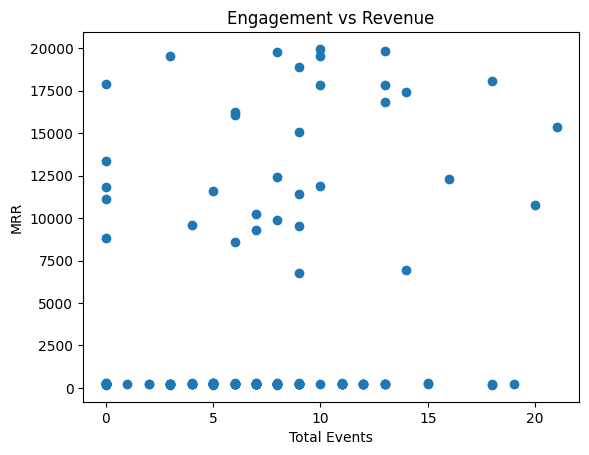

In [31]:
# 7. Scatter Plot (Engagement vs Revenue)
plt.figure()
plt.scatter(data["total_events"], data["mrr"])
plt.xlabel("Total Events")
plt.ylabel("MRR")
plt.title("Engagement vs Revenue")
plt.show()

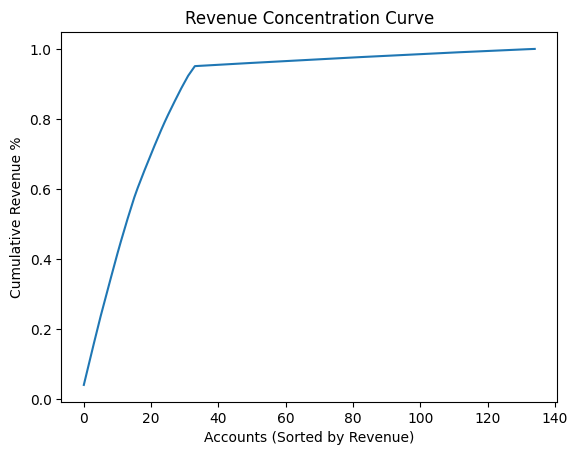

In [32]:
# 8. Pareto Curve (Cumulative Revenue)
# ==============================
plt.figure()
plt.plot(data["cumulative_revenue_pct"])
plt.xlabel("Accounts (Sorted by Revenue)")
plt.ylabel("Cumulative Revenue %")
plt.title("Revenue Concentration Curve")
plt.show()


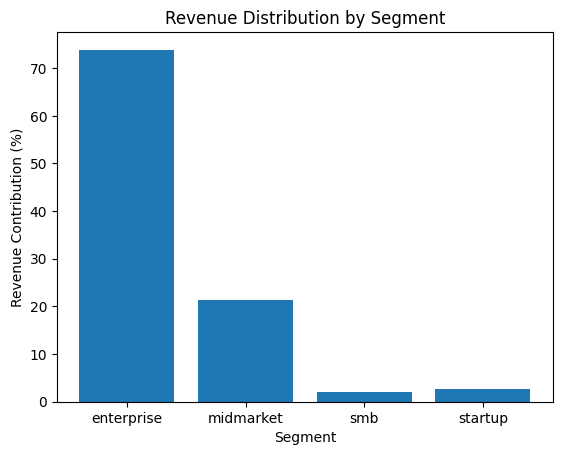

In [34]:
# 9. Segment Revenue Bar Chart
# ==============================
plt.figure()
plt.bar(segment_revenue["segment"], segment_revenue["revenue_pct"])
plt.xlabel("Segment")
plt.ylabel("Revenue Contribution (%)")
plt.title("Revenue Distribution by Segment")
plt.show()